<a href="https://colab.research.google.com/github/ScholarlyInsane/ml-practice/blob/main/class13%2650%2C52%2C53.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape

(100, 4)

In [ ]:
df=df.iloc[:,1:]  #to remove the unwanted column 0 in the prev dataset (iloc[row,column include])

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.corr()['placement']

,placement
cgpa,0.821688
iq,-0.083031
placement,1.000000


In [ ]:
import matplotlib.pyplot as plt


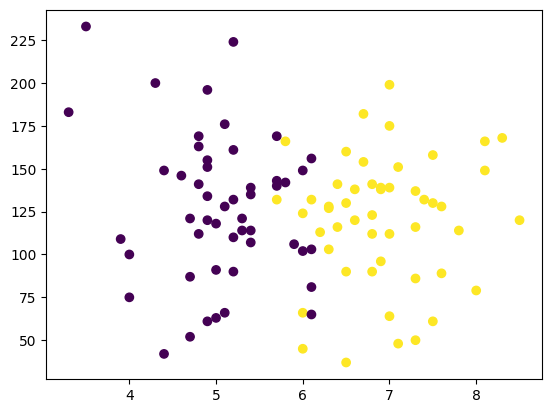

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [ ]:
X.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [ ]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [ ]:
X_train


,cgpa,iq
57,6.5,130.0
27,6.0,124.0
53,8.3,168.0
76,4.9,155.0
88,4.4,149.0
...,...,...
61,7.3,137.0
36,5.7,140.0
64,7.0,64.0
52,7.0,175.0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

In [ ]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
X_train


array([[ 0.47865167,  0.18369514],
       [ 0.03907361,  0.0380338 ],
       [ 2.06113272,  1.10621698],
       [-0.92799814,  0.7906174 ],
       [-1.36757621,  0.64495606],
       [ 1.18197658, -0.88448805],
       [ 0.03907361, -0.4960578 ],
       [-1.01591376,  1.13049387],
       [ 1.35780781, -1.49141031],
       [-0.57633569, -0.20473511],
       [ 1.62155465, -0.20473511],
       [-0.48842008,  0.40218715],
       [-1.36757621, -1.95267124],
       [ 0.39073606, -0.15618133],
       [-1.80715428, -0.32611956],
       [-0.48842008,  0.30507959],
       [-0.13675762,  1.0576632 ],
       [-0.92799814,  0.69350984],
       [ 0.83031413, -0.64171914],
       [ 0.03907361, -1.37002586],
       [ 0.74239852, -0.25328889],
       [-0.75216692,  1.30043211],
       [-0.48842008, -0.37467335],
       [-2.15881674,  2.68421487],
       [ 0.47865167, -0.78738049],
       [-0.6642513 ,  0.93627875],
       [ 0.56656729, -0.05907377],
       [-0.48842008, -0.20473511],
       [-0.92799814,

In [ ]:
Y_train

,placement
57,1
27,1
53,1
76,0
88,0
...,...
61,1
36,0
64,1
52,1


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()

In [ ]:
#model training
clf.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
yy_pred=clf.predict(X_test)

In [ ]:
Y_test

,placement
54,1
69,1
28,0
43,1
38,1
22,0
8,0
21,1
60,1
24,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(yy_pred,Y_test)

0.9

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

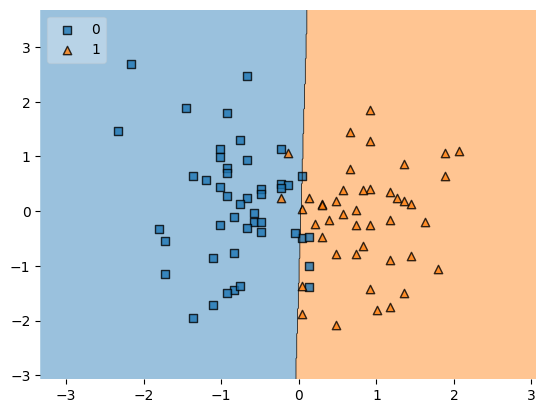

In [ ]:
# Plotting decision regions
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [ ]:
import pickle #converts object to file and can be picked to be used in other environment

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))  #wb=write binary mode

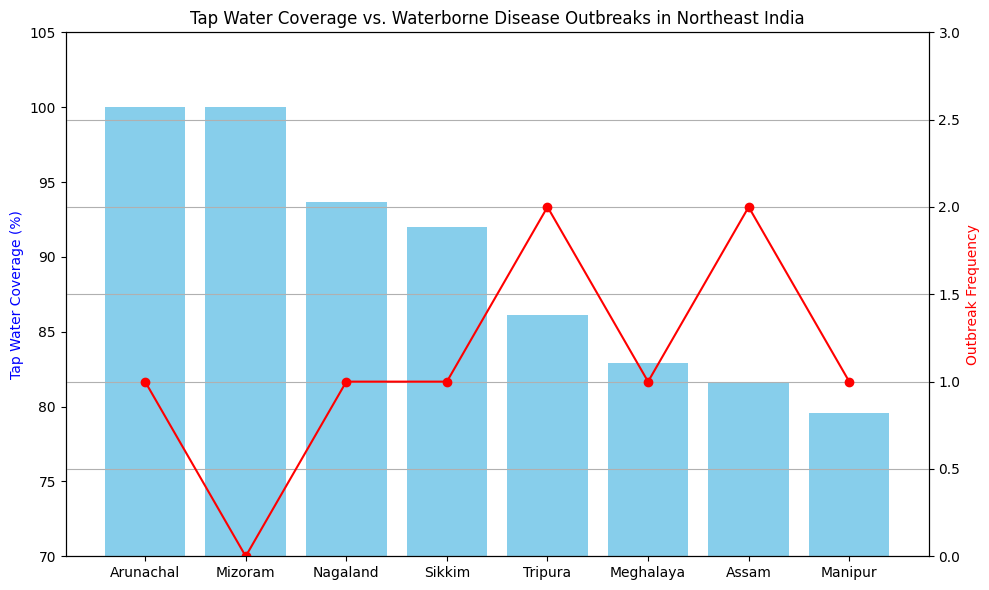

In [ ]:
import matplotlib.pyplot as plt

states = ['Arunachal', 'Mizoram', 'Nagaland', 'Sikkim', 'Tripura', 'Meghalaya', 'Assam', 'Manipur']
tap_water = [100.00, 100.00, 93.68, 91.97, 86.12, 82.90, 81.63, 79.59]
outbreaks = [1, 0, 1, 1, 2, 1, 2, 1]

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(states, tap_water, color='skyblue', label='Tap Water Coverage (%)')
ax1.set_ylabel('Tap Water Coverage (%)', color='blue')
ax1.set_ylim(70, 105)

ax2 = ax1.twinx()
ax2.plot(states, outbreaks, color='red', marker='o', label='Outbreaks')
ax2.set_ylabel('Outbreak Frequency', color='red')
ax2.set_ylim(0, 3)

plt.title('Tap Water Coverage vs. Waterborne Disease Outbreaks in Northeast India')
plt.grid(True)
plt.tight_layout()
plt.show()

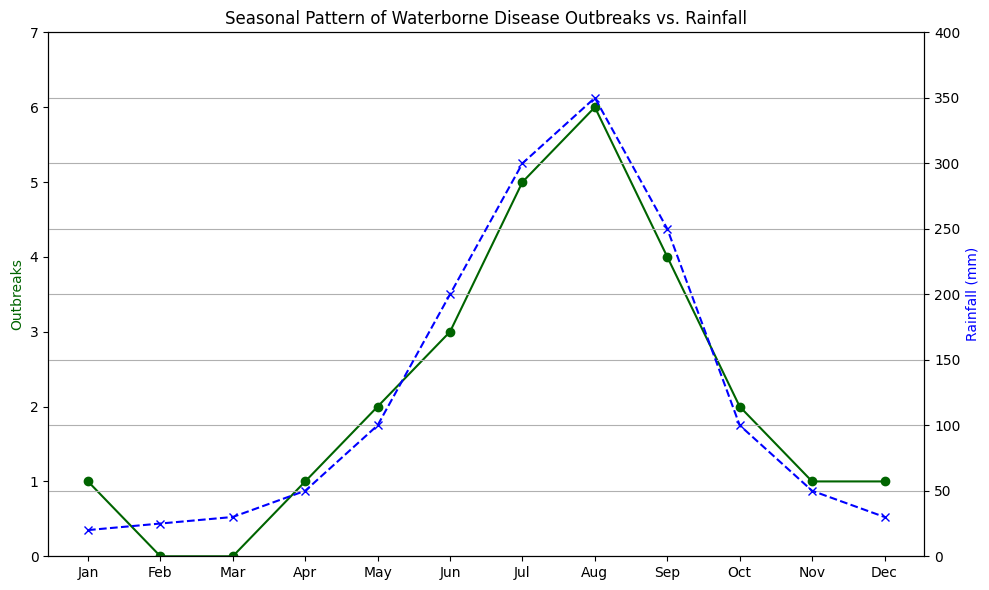

In [ ]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
outbreaks = [1, 0, 0, 1, 2, 3, 5, 6, 4, 2, 1, 1]
rainfall = [20, 25, 30, 50, 100, 200, 300, 350, 250, 100, 50, 30]

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(months, outbreaks, color='darkgreen', marker='o', label='Outbreaks')
ax1.set_ylabel('Outbreaks', color='darkgreen')
ax1.set_ylim(0, 7)

ax2 = ax1.twinx()
ax2.plot(months, rainfall, color='blue', linestyle='--', marker='x', label='Rainfall (mm)')
ax2.set_ylabel('Rainfall (mm)', color='blue')
ax2.set_ylim(0, 400)

plt.title('Seasonal Pattern of Waterborne Disease Outbreaks vs. Rainfall')
plt.grid(True)
plt.tight_layout()
plt.show()


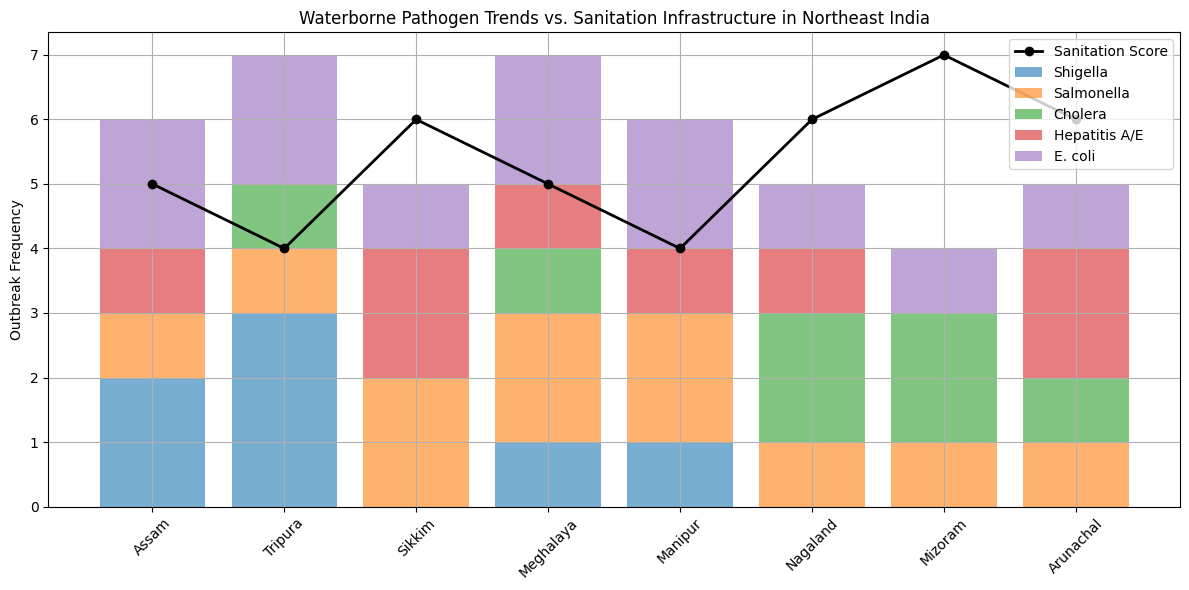

In [ ]:
import matplotlib.pyplot as plt

states = ['Assam', 'Tripura', 'Sikkim', 'Meghalaya', 'Manipur', 'Nagaland', 'Mizoram', 'Arunachal']
# Outbreaks by dominant pathogen (approximate counts from reports)
shigella = [2, 3, 0, 1, 1, 0, 0, 0]
salmonella = [1, 1, 2, 2, 2, 1, 1, 1]
cholera = [0, 1, 0, 1, 0, 2, 2, 1]
hepatitis = [1, 0, 2, 1, 1, 1, 0, 2]
ecoli = [2, 2, 1, 2, 2, 1, 1, 1]

# Sanitation infrastructure score (0–10 scale based on coverage, FSSM, and water safety)
sanitation_score = [5, 4, 6, 5, 4, 6, 7, 6]

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(states, sanitation_score, color='black', marker='o', linewidth=2, label='Sanitation Score')

ax.bar(states, shigella, alpha=0.6, label='Shigella')
ax.bar(states, salmonella, alpha=0.6, bottom=shigella, label='Salmonella')
bottom2 = [shigella[i]+salmonella[i] for i in range(len(states))]
ax.bar(states, cholera, alpha=0.6, bottom=bottom2, label='Cholera')
bottom3 = [bottom2[i]+cholera[i] for i in range(len(states))]
ax.bar(states, hepatitis, alpha=0.6, bottom=bottom3, label='Hepatitis A/E')
bottom4 = [bottom3[i]+hepatitis[i] for i in range(len(states))]
ax.bar(states, ecoli, alpha=0.6, bottom=bottom4, label='E. coli')

ax.set_ylabel('Outbreak Frequency')
ax.set_title('Waterborne Pathogen Trends vs. Sanitation Infrastructure in Northeast India')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**DAY 50 ML chase**

In [ ]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [ ]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [ ]:
df.shape

(100, 3)

In [ ]:
df.head

<bound method NDFrame.head of     feature1  feature2      target
0   0.384409  1.531741  121.126197
1   1.452976  1.483788  102.447879
2  -1.337185 -0.287778  -78.783243
3  -1.464995  1.008735  -93.382710
4   0.661779 -1.104220  107.788972
..       ...       ...         ...
95 -0.690963 -1.903862  -89.095975
96  2.020186 -0.660365  140.253983
97  1.107044 -0.907442   45.505351
98  0.899522  0.227459  115.652342
99 -1.898427  0.047938  -36.925755

[100 rows x 3 columns]>

In [ ]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 38.3035127274846
MSE 2291.712488799014
R2 score 0.790761872689242


In [ ]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

z_final = lr.predict(final).reshape(10,10)

z = z_final

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T


fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [ ]:
lr.intercept_

np.float64(-1.9809291514602512)

In [ ]:
lr.coef_

array([75.57142129, 25.67420488])

**DAY 52 BATCH GRADIENT DESCENT**

In [ ]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
X,y = load_diabetes(return_X_y=True)

In [ ]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [ ]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)


0.4399338661568968

In [ ]:
X_train.shape

(353, 10)

In [ ]:
class GDRegressor:

    def __init__(self,learning_rate=0.01,epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            # update all the coef and the intercept
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            #print("Shape of y_hat",y_hat.shape)
            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)

            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_,self.coef_)

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [ ]:
gdr = GDRegressor(epochs=1000,learning_rate=0.5)
gdr.fit(X_train,y_train)

152.01351687661833 [  14.38990585 -173.7235727   491.54898524  323.91524824  -39.32648042
 -116.01061213 -194.04077415  103.38135565  451.63448787   97.57218278]


In [ ]:
y_pred = gdr.predict(X_test)
r2_score(y_test,y_pred)


0.4534503034722803

**DAY 53 POLYNOMIAL REGRESSION**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [ ]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

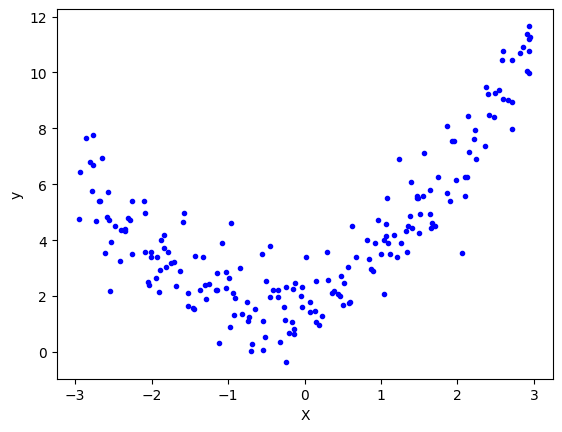

In [ ]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
# Applying linear regression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

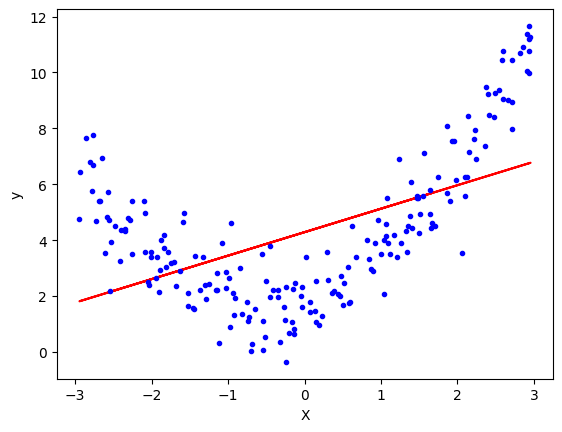

In [ ]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
#Applying Polynomial Linear Regression
# degree 2
poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)
print(X_train[0])
print(X_train_trans[0])

[-2.54931413]
[ 1.         -2.54931413  6.49900255]


In [ ]:
# include_bias parameter
lr = LinearRegression()
lr.fit(X_train_trans,y_train)
LinearRegression()
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.8409697700421217

[[0.         0.78397816 0.77926565]]
[1.99080274]


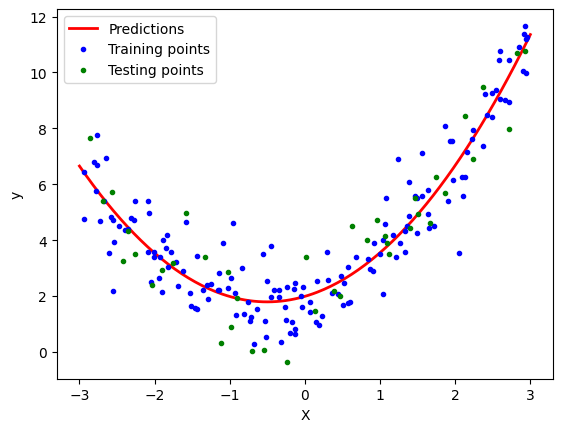

In [ ]:
print(lr.coef_)
print(lr.intercept_)

X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()